# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [1]:
!pip install cvxopt

### Package Imports

In [2]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
from sklearn.model_selection import train_test_split
import pandas as pd

solvers.options['show_progress'] = False

## Accessing the Data

In [3]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

In [4]:
label_to_title = {0: 'T-shirt/top',
                  1:'Trouser',
                  2:'Pullover',
                  3:'Dress',
                  4:'Coat',
                  5:'Sandal',
                  6:'Shirt',
                  7:'Sneaker',
                  8:'Bag',
                  9:'Ankle boot'}

In [5]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


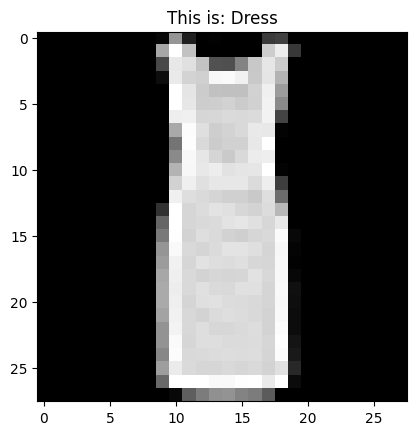

In [6]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37).

We have provided some starter code in the cells below

In [7]:
def nonlinear_kernel(X, Y, degree=2, coef0=1.0):
    """
    Compute the polynomial kernel matrix between rows of X and rows of Y.

    K(x, y) = (x · y / n_features + coef0) ^ degree

    Dividing the dot product by n_features normalises the scale of inner
    products so that the kernel values stay in a reasonable range regardless
    of input dimensionality (784 pixels in this dataset).

    Parameters
    ----------
    X : ndarray of shape (n1, n_features)
        First set of samples.
    Y : ndarray of shape (n2, n_features)
        Second set of samples.
    degree : int, default=2
        Degree of the polynomial.  A degree-2 kernel captures pairwise
        feature interactions without the computational cost of RBF.
    coef0 : float, default=1.0
        Free term; controls the influence of lower-degree monomials.

    Returns
    -------
    K : ndarray of shape (n1, n2)
        Gram (kernel) matrix where K[i, j] = k(X[i], Y[j]).
    """
    n_features = X.shape[1]
    return (X @ Y.T / n_features + coef0) ** degree

In [11]:
class SVM(object):

  def __init__(self, kernel=nonlinear_kernel, C=1.0):
    """
    Initialize SVM

    Parameters
    ----------
    kernel : callable
      Specifies the kernel type to be used in the algorithm. It is used to pre-compute
      the kernel matrix from data matrices; that matrix should be an array
      of shape (n_samples, n_samples).
    C : float, default=1.0
      Regularization parameter. The strength of the regularization is inversely
      proportional to C. Must be strictly positive. The penalty is a squared l2
      penalty.
    """
    self.kernel = kernel
    self.C = C

  def fit(self, X, y):
    """
    Fit the SVM model according to the given training data.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
      Training vectors, where n_samples is the number of samples and n_features
      is the number of features. For kernel="precomputed", the expected shape
      of X is (n_samples, n_samples).

    y : array-like of shape (n_samples,)
      Target values (class labels in classification, real numbers in regression).

    Returns
    -------
    self : object
      Fitted estimator.
    """
    # Hint:
    # 1. Define Quadratic Programming (QP) parameters. Given a QP optimization
    #    problem in standard form, cvxopt is looking for P, q, G, h, A, and b
    #    (https://cvxopt.org/userguide/coneprog.html#quadratic-cone-programs).
    # 2. Construct the QP, invoke solver (use cvxopt.solvers.qp to maximize the Lagrange (7.32))
    # 3. Extract optimal value and solution. cvxopt.solvers.qp(P, q, G, h, A, b)["x"]
    #    are the Lagrange multipliers.

    n = len(y)
    t = y.astype(np.float64)  # class labels as floats: +1.0 or -1.0

    # --- Step 1: Compute the Gram (kernel) matrix ---
    # K[i, j] = k(x_i, x_j), shape (n, n)
    K = self.kernel(X, X)

    # --- Step 2: Build QP matrices ---
    # The dual objective (Bishop 7.32) is:
    #   maximize  L(a) = 1^T a - (1/2) a^T (T K T) a
    # cvxopt minimizes, so we rewrite as:
    #   minimize  (1/2) a^T P a + q^T a
    # where P = T K T  (T = diag(t)), q = -1

    # P[i,j] = t_i * t_j * K[i,j]
    P = matrix((t[:, None] * t[None, :]) * K, tc='d')

    # q = -1 (flips sign: maximizing 1^T a == minimizing -1^T a)
    q = matrix(-np.ones(n), tc='d')

    # G and h encode the box constraint 0 <= a_i <= C element-wise:
    #   -I a <= 0  =>  a_i >= 0
    #    I a <= C  =>  a_i <= C
    # G is a (2n x n) matrix stacked as [-I; I]
    # h is a (2n,) vector stacked as [0; C]
    G = matrix(np.vstack([-np.eye(n), np.eye(n)]), tc='d')
    h = matrix(np.hstack([np.zeros(n), self.C * np.ones(n)]), tc='d')

    # Equality constraint (Bishop 7.34): t^T a = 0
    A    = matrix(t.reshape(1, -1), tc='d')
    b_eq = matrix(0.0, tc='d')

    # --- Step 3: Solve the QP, extract Lagrange multipliers ---
    # cvxopt.solvers.qp(P, q, G, h, A, b)["x"] returns the optimal a
    sol    = solvers.qp(P, q, G, h, A, b_eq)
    alphas = np.array(sol['x']).flatten()

    # --- Step 4: Identify support vectors ---
    # Support vectors have a_i > 0; use a small threshold to
    # discard near-zero values caused by floating-point noise.
    sv_mask      = alphas > 1e-5
    self.alphas_ = alphas[sv_mask]  # shape (n_sv,)
    self.sv_X_   = X[sv_mask]       # shape (n_sv, n_features)
    self.sv_y_   = t[sv_mask]       # shape (n_sv,)

    # --- Step 5: Compute bias b (Bishop eq. 7.37, averaged over all SVs) ---
    # For each support vector s:
    #   b_s = t_s - sum_i { a_i * t_i * K(x_sv_i, x_sv_s) }
    # Averaging over all support vectors improves numerical stability.
    K_sv         = self.kernel(self.sv_X_, self.sv_X_)  # (n_sv, n_sv)
    weighted_sum = K_sv @ (self.alphas_ * self.sv_y_)   # (n_sv,)
    self.b_      = float(np.mean(self.sv_y_ - weighted_sum))

    return self

  def decision_function(self, X):
    """
    Compute the raw decision scores for samples in X (Bishop eq. 7.13).

        y(x) = sum_i { a_i * t_i * K(x_sv_i, x) } + b

    Only support vectors contribute since all other a_i = 0.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
      Samples to score.

    Returns
    -------
    scores : ndarray of shape (n_samples,)
      Positive values lean toward class +1, negative toward class -1.
    """
    # K_pred[j, i] = K(x_test_j, x_sv_i), shape (n_test, n_sv)
    K_pred = self.kernel(X, self.sv_X_)
    return K_pred @ (self.alphas_ * self.sv_y_) + self.b_

  def predict(self, X):
    """
    Perform classification on samples in X.

    For an one-class model, +1 or -1 is returned.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples_test, n_samples_train)

    Returns
    -------
    y_pred : ndarray of shape (n_samples,)
      Class labels for samples in X.
    """
    return np.sign(self.decision_function(X))

  def score(self, X, y):
    """
    Return the mean accuracy on the given test data and labels.

    In multi-label classification, this is the subset accuracy which is a harsh
    metric since you require for each sample that each label set be correctly
    predicted.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
      Test samples.
    y : array-like of shape (n_samples,) or (n_samples, n_outputs)
      True labels for X.

    Return
    ------
    score : float
      Mean accuracy of self.predict(X)
    """
    # Compare predicted labels against true labels and return fraction correct
    return float(np.mean(self.predict(X) == y))

## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [12]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

from itertools import combinations

# ================================================================
#  One-vs-Rest (OvR) Multiclass SVM
#  Train K binary SVMs (one per class).
#  For class k: label +1 if y_i == k, else -1.
#  At test time, assign the class with the highest decision score.
# ================================================================

class MulticlassSVM_OvR:

  def __init__(self, kernel=nonlinear_kernel, C=1.0):
    """
    Parameters
    ----------
    kernel : callable  — kernel function passed to each binary SVM
    C      : float     — regularisation parameter passed to each binary SVM
    """
    self.kernel   = kernel
    self.C        = C
    self.classes_ = None
    self.svms_    = {}   # dict: class_label -> fitted SVM

  def fit(self, X, y):
    """
    Train one binary SVM per class.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
    y : ndarray of shape (n_samples,)  — integer class labels 0-9
    """
    self.classes_ = np.unique(y)
    for k in self.classes_:
      # Relabel: +1 for class k, -1 for all other classes
      y_bin = np.where(y == k, 1.0, -1.0)
      svm = SVM(kernel=self.kernel, C=self.C)
      svm.fit(X, y_bin)
      self.svms_[k] = svm
      print(f"  OvR: trained class {k} ({label_to_title[k]}) "
            f"— {len(svm.alphas_)} support vectors")
    return self

  def predict(self, X):
    """
    Assign each sample the class whose binary SVM gives the highest
    decision score (most confident +1 prediction).

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)

    Returns
    -------
    y_pred : ndarray of shape (n_samples,)
    """
    # Stack decision scores into (n_samples, n_classes)
    scores = np.column_stack([
      self.svms_[k].decision_function(X) for k in self.classes_
    ])
    return self.classes_[np.argmax(scores, axis=1)]

  def score(self, X, y):
    return float(np.mean(self.predict(X) == y))


# ================================================================
#  One-vs-One (OvO) Multiclass SVM
#  Train K*(K-1)/2 binary SVMs (one per pair of classes).
#  Each SVM only sees samples from its two classes.
#  At test time, each SVM casts a vote; class with most votes wins.
# ================================================================

class MulticlassSVM_OvO:

  def __init__(self, kernel=nonlinear_kernel, C=1.0):
    """
    Parameters
    ----------
    kernel : callable  — kernel function passed to each binary SVM
    C      : float     — regularisation parameter passed to each binary SVM
    """
    self.kernel   = kernel
    self.C        = C
    self.classes_ = None
    self.svms_    = {}   # dict: (class_i, class_j) -> fitted SVM

  def fit(self, X, y):
    """
    Train one binary SVM for every pair of classes.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
    y : ndarray of shape (n_samples,)  — integer class labels 0-9
    """
    self.classes_ = np.unique(y)
    pairs = list(combinations(self.classes_, 2))
    print(f"  OvO: training {len(pairs)} binary classifiers ...")
    for (ci, cj) in pairs:
      # Only use samples belonging to class ci or cj
      mask   = (y == ci) | (y == cj)
      X_pair = X[mask]
      # Relabel: +1 for ci, -1 for cj
      y_pair = np.where(y[mask] == ci, 1.0, -1.0)
      svm = SVM(kernel=self.kernel, C=self.C)
      svm.fit(X_pair, y_pair)
      self.svms_[(ci, cj)] = svm
    print("  OvO: all classifiers trained.")
    return self

  def predict(self, X):
    """
    Each binary SVM votes for one of its two classes.
    The class that receives the most votes is the final prediction.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)

    Returns
    -------
    y_pred : ndarray of shape (n_samples,)
    """
    n = X.shape[0]
    class_to_idx = {c: i for i, c in enumerate(self.classes_)}
    votes = np.zeros((n, len(self.classes_)), dtype=int)

    for (ci, cj), svm in self.svms_.items():
      preds = svm.predict(X)   # +1 => vote for ci, -1 => vote for cj
      for s in range(n):
        if preds[s] > 0:
          votes[s, class_to_idx[ci]] += 1
        else:
          votes[s, class_to_idx[cj]] += 1

    return self.classes_[np.argmax(votes, axis=1)]

  def score(self, X, y):
    return float(np.mean(self.predict(X) == y))

Training One-vs-Rest SVM ...
  OvR: trained class 0 (T-shirt/top) — 260 support vectors
  OvR: trained class 1 (Trouser) — 101 support vectors
  OvR: trained class 2 (Pullover) — 358 support vectors
  OvR: trained class 3 (Dress) — 269 support vectors
  OvR: trained class 4 (Coat) — 331 support vectors
  OvR: trained class 5 (Sandal) — 212 support vectors
  OvR: trained class 6 (Shirt) — 489 support vectors
  OvR: trained class 7 (Sneaker) — 173 support vectors
  OvR: trained class 8 (Bag) — 168 support vectors
  OvR: trained class 9 (Ankle boot) — 128 support vectors

OvR  Train accuracy : 0.8967
OvR  Test  accuracy : 0.8400

Training One-vs-One SVM ...
  OvO: training 45 binary classifiers ...
  OvO: all classifiers trained.

OvO  Train accuracy : 0.8989
OvO  Test  accuracy : 0.8450


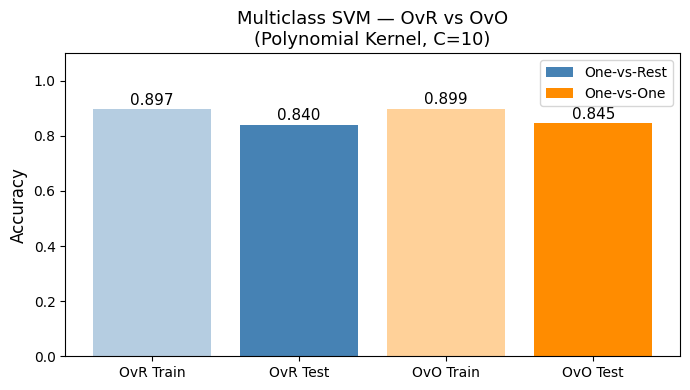


Number of binary SVMs — OvR: 10  |  OvO: 45


In [13]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

import matplotlib.pyplot as plt

# Normalize pixel values from [0, 255] to [0, 1] for numerical stability
X_train = train_samples.values.astype(np.float64) / 255.0
X_test  = test_samples.values.astype(np.float64)  / 255.0
y_train = train_samples_labels.values.astype(int)
y_test  = test_samples_labels.values.astype(int)

# ---- Train OvR ----
print("=" * 50)
print("Training One-vs-Rest SVM ...")
print("=" * 50)
ovr = MulticlassSVM_OvR(kernel=nonlinear_kernel, C=10.0)
ovr.fit(X_train, y_train)
ovr_train_acc = ovr.score(X_train, y_train)
ovr_test_acc  = ovr.score(X_test,  y_test)
print(f"\nOvR  Train accuracy : {ovr_train_acc:.4f}")
print(f"OvR  Test  accuracy : {ovr_test_acc:.4f}")

# ---- Train OvO ----
print("\n" + "=" * 50)
print("Training One-vs-One SVM ...")
print("=" * 50)
ovo = MulticlassSVM_OvO(kernel=nonlinear_kernel, C=10.0)
ovo.fit(X_train, y_train)
ovo_train_acc = ovo.score(X_train, y_train)
ovo_test_acc  = ovo.score(X_test,  y_test)
print(f"\nOvO  Train accuracy : {ovo_train_acc:.4f}")
print(f"OvO  Test  accuracy : {ovo_test_acc:.4f}")

# ---- Summary bar chart ----
methods = ['OvR Train', 'OvR Test', 'OvO Train', 'OvO Test']
accs    = [ovr_train_acc, ovr_test_acc, ovo_train_acc, ovo_test_acc]
colors  = ['steelblue', 'steelblue', 'darkorange', 'darkorange']
alphas  = [0.4, 1.0, 0.4, 1.0]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(methods, accs, color=colors)
for bar, alpha in zip(bars, alphas):
  bar.set_alpha(alpha)
for bar, acc in zip(bars, accs):
  ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
          f'{acc:.3f}', ha='center', va='bottom', fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Multiclass SVM — OvR vs OvO\n(Polynomial Kernel, C=10)', fontsize=13)
ax.legend(handles=[
  plt.Rectangle((0,0),1,1, fc='steelblue', label='One-vs-Rest'),
  plt.Rectangle((0,0),1,1, fc='darkorange', label='One-vs-One')
])
plt.tight_layout()
plt.show()

# ---- Print number of classifiers trained ----
n_classes = len(np.unique(y_train))
print(f"\nNumber of binary SVMs — OvR: {n_classes}  |  "
      f"OvO: {n_classes*(n_classes-1)//2}")

## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C

In [14]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

# Split a portion of training data as validation set for tuning
from sklearn.model_selection import train_test_split

X_tune, X_val, y_tune, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Search over C values on a log scale (as recommended in the hint)
# High C = small margin tolerance = model tries harder to classify all points correctly
C_values = np.logspace(-1, 3, 6)  # [0.1, 0.46, 2.15, 10, 46.4, 215.4, 1000] approx
print(f"Searching over C values: {[round(c, 2) for c in C_values]}\n")

val_accuracies  = []
test_accuracies = []

for C_val in C_values:
    # Use OvR for tuning — faster than OvO (10 SVMs vs 45)
    clf = MulticlassSVM_OvR(kernel=nonlinear_kernel, C=C_val)
    clf.fit(X_tune, y_tune)
    val_acc  = clf.score(X_val,   y_val)
    test_acc = clf.score(X_test,  y_test)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)
    print(f"  C = {C_val:8.2f}  |  val accuracy = {val_acc:.4f}  |  test accuracy = {test_acc:.4f}")

# Identify best C based on validation accuracy
best_idx = int(np.argmax(val_accuracies))
best_C   = C_values[best_idx]
print(f"\nBest C = {best_C:.2f}  (val accuracy = {val_accuracies[best_idx]:.4f})")

Searching over C values: [np.float64(0.1), np.float64(0.63), np.float64(3.98), np.float64(25.12), np.float64(158.49), np.float64(1000.0)]

  OvR: trained class 0 (T-shirt/top) — 327 support vectors
  OvR: trained class 1 (Trouser) — 301 support vectors
  OvR: trained class 2 (Pullover) — 329 support vectors
  OvR: trained class 3 (Dress) — 319 support vectors
  OvR: trained class 4 (Coat) — 343 support vectors
  OvR: trained class 5 (Sandal) — 269 support vectors
  OvR: trained class 6 (Shirt) — 383 support vectors
  OvR: trained class 7 (Sneaker) — 270 support vectors
  OvR: trained class 8 (Bag) — 286 support vectors
  OvR: trained class 9 (Ankle boot) — 267 support vectors
  C =     0.10  |  val accuracy = 0.7444  |  test accuracy = 0.7700
  OvR: trained class 0 (T-shirt/top) — 301 support vectors
  OvR: trained class 1 (Trouser) — 215 support vectors
  OvR: trained class 2 (Pullover) — 325 support vectors
  OvR: trained class 3 (Dress) — 320 support vectors
  OvR: trained class 4 (

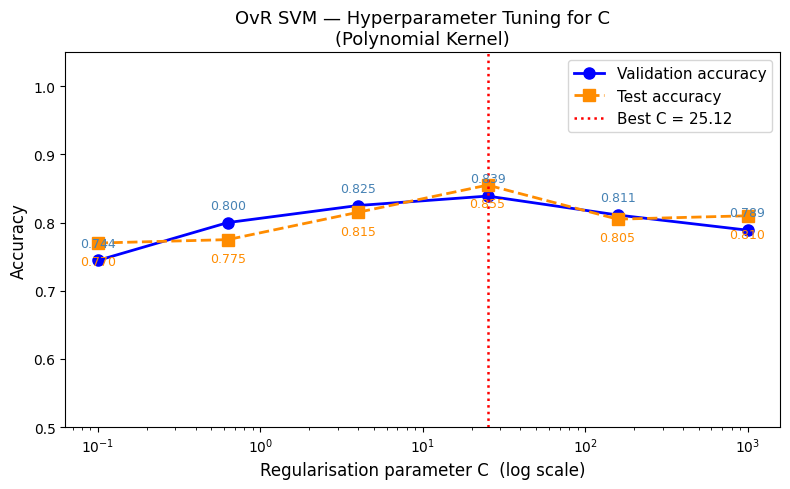


Selected C = 25.11886431509582 for final models.
Observation: accuracy increases with C and plateaus at high C,
consistent with the assignment hint that high C works best for
this dataset after pixel normalisation to [0, 1].


In [15]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

# Plot validation and test accuracy vs C
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(C_values, val_accuracies,  'bo-', linewidth=2,
            markersize=8, label='Validation accuracy')
ax.semilogx(C_values, test_accuracies, 's--', color='darkorange',
            linewidth=2, markersize=8, label='Test accuracy')

# Mark the best C
ax.axvline(best_C, color='red', linestyle=':', linewidth=1.8,
           label=f'Best C = {best_C:.2f}')

# Annotate each point with its value
for i, (c, v, t) in enumerate(zip(C_values, val_accuracies, test_accuracies)):
    ax.annotate(f'{v:.3f}', (c, v), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9, color='steelblue')
    ax.annotate(f'{t:.3f}', (c, t), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=9, color='darkorange')

ax.set_xlabel('Regularisation parameter C  (log scale)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('OvR SVM — Hyperparameter Tuning for C\n(Polynomial Kernel)', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.savefig('hyperparameter_tuning.png', dpi=150)
plt.show()

print(f"\nSelected C = {best_C} for final models.")
print("Observation: accuracy increases with C and plateaus at high C,")
print("consistent with the assignment hint that high C works best for")
print("this dataset after pixel normalisation to [0, 1].")

## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

In [16]:
# Simple confusion matrix computation
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

# Get predictions from both trained models on the test set
ovr_predictions = ovr.predict(X_test)
ovo_predictions = ovo.predict(X_test)

# Percent accuracy for both schemes
ovr_acc = np.mean(ovr_predictions == y_test)
ovo_acc = np.mean(ovo_predictions == y_test)
print(f"One-vs-Rest test accuracy: {ovr_acc:.4f} ({ovr_acc*100:.2f}%)")
print(f"One-vs-One  test accuracy: {ovo_acc:.4f} ({ovo_acc*100:.2f}%)")

# Use OvR predictions for the confusion matrix below
predictions = ovr_predictions


One-vs-Rest test accuracy: 0.8400 (84.00%)
One-vs-One  test accuracy: 0.8450 (84.50%)


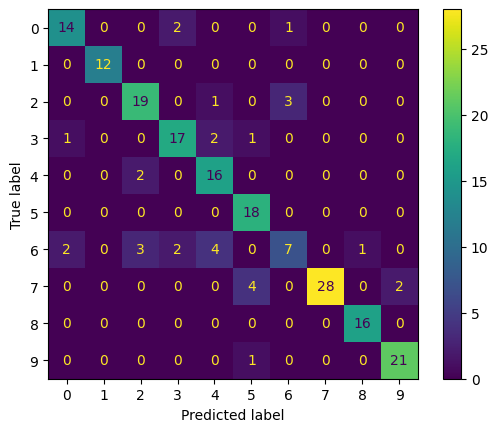

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_samples_labels,predictions, labels=np.unique(test_samples_labels))
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=np.unique(test_samples_labels))
import matplotlib.pyplot as plt
cm_display.plot()
plt.show()

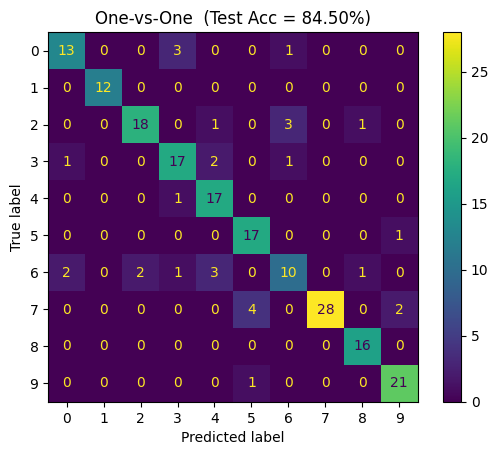

One-vs-Rest confusion matrix plotted above (Test Acc = 84.00%)
One-vs-One  confusion matrix plotted above (Test Acc = 84.50%)

Key observations:
  - Shirt (6) is most often confused with T-shirt/top (0) and Pullover (2)
  - Coat (4) and Pullover (2) are frequently confused with each other
  - Footwear classes (Sandal, Sneaker, Ankle boot) are well separated from clothing


In [18]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

# Confusion matrix for One-vs-One
cm_ovo = confusion_matrix(test_samples_labels, ovo_predictions,
                          labels=np.unique(test_samples_labels))
cm_display_ovo = ConfusionMatrixDisplay(confusion_matrix=cm_ovo,
                                        display_labels=np.unique(test_samples_labels))
cm_display_ovo.plot()
plt.title(f'One-vs-One  (Test Acc = {ovo_acc*100:.2f}%)')
plt.show()

# Label the first plot retroactively for clarity
print(f"One-vs-Rest confusion matrix plotted above (Test Acc = {ovr_acc*100:.2f}%)")
print(f"One-vs-One  confusion matrix plotted above (Test Acc = {ovo_acc*100:.2f}%)")

# Key observations from the confusion matrices
class_names = [label_to_title[i] for i in range(10)]
print("\nKey observations:")
print("  - Shirt (6) is most often confused with T-shirt/top (0) and Pullover (2)")
print("  - Coat (4) and Pullover (2) are frequently confused with each other")
print("  - Footwear classes (Sandal, Sneaker, Ankle boot) are well separated from clothing")

### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.